In [16]:
# --- repo bootstrap: make src/ + this domain's config importable, run from repo root ---
#   src/                    shared library, in every container
#   domains/credit_risk/    THIS domain's model_config.py — only in the
#                           credit-risk containers, so the domain-agnostic stages
#                           physically cannot import domain settings
import sys, os
from pathlib import Path
_ROOT = Path.cwd()
while _ROOT != _ROOT.parent and not (_ROOT / 'src').is_dir():
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / 'src'))
sys.path.insert(0, str(_ROOT / 'domains' / 'credit_risk'))
os.chdir(_ROOT)

# Aave V3.1 — model results (staged)

Results are read in STAGES — baselines first, then each model family against
them, then the feature evidence, then the PRI. Nothing is compared across
families until the FINAL stage, where the val-selected champion (never
test-selected), the meta-PRI and the baselines meet once, with confidence
intervals. Lead-time backtesting scores TEST only (val tuned the blend).

In [17]:
import warnings
warnings.filterwarnings("ignore")

import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

import model_config as cfg
import model_persistence as mps
import model_benchmarks as mbench
import adv_validation as adv
import EDA

DATA_DIR = Path("transformed_data")
PREVIEW_ROWS = 5

results = mps.load_model_results()
pri = pd.read_csv(Path(cfg.MODEL_RESULTS_DIR) / "pri_timeseries.csv")
DF_model = pd.read_csv(DATA_DIR / "DF_model_dataset_24h.csv")
manifest = json.load(open(Path(cfg.MODEL_RESULTS_DIR) / "run_manifest.json"))
print(f" {len(results)} model results | PRI series {pri.shape[0]} rows")
print(f" run: {manifest['run_at_utc']} | splits {manifest['split_rows']} | "
      f"{manifest['n_features']} features | embargo {manifest['embargo_days']}d")

 29 model results | PRI series 343 rows
 run: 2026-07-30T15:40:34.773389+00:00 | splits {'train': 189, 'val': 82, 'test': 72} | 53 features | embargo 7d


## Stage 1 — baselines

Persistence (today's stress carried forward) and prevalence (constant rate).
Every later number is only as good as its distance from these.

In [18]:
for stem in ("baseline_persistence__classifier", "baseline_prevalence__classifier",
             "baseline_persistence__regressor", "baseline_median__regressor"):
    res = results.get(stem)
    if res:
        print(f"══ {res['name']}  [{res['kind']}] ══")
        display(mbench.model_scorecard(res))

══ baseline_persistence  [classifier] ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.579,0.292,0.398,None,47,189,None,None
1,y_stress_1d,val,0.611,0.412,0.509,None,28,82,None,None
2,y_stress_1d,test,0.509,0.407,0.574,None,29,72,None,"[0.379, 0.681]"
3,y_stress_3d,train,0.550,0.273,0.398,None,47,189,None,None
4,y_stress_3d,val,0.589,0.420,0.536,None,30,82,None,None
5,y_stress_3d,test,0.533,0.392,0.545,None,27,72,None,None
6,y_stress_7d,train,0.555,0.270,0.391,None,46,189,None,None
7,y_stress_7d,val,0.631,0.468,0.549,None,31,82,None,None
8,y_stress_7d,test,0.559,0.761,0.848,None,53,72,None,None


══ baseline_prevalence  [classifier] ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.5,0.249,0.398,None,47,189,None,None
1,y_stress_1d,val,0.5,0.341,0.509,None,28,82,None,None
2,y_stress_1d,test,0.5,0.403,0.574,None,29,72,None,"[0.500, 0.500]"
3,y_stress_3d,train,0.5,0.249,0.398,None,47,189,None,None
4,y_stress_3d,val,0.5,0.366,0.536,None,30,82,None,None
5,y_stress_3d,test,0.5,0.375,0.545,None,27,72,None,None
6,y_stress_7d,train,0.5,0.243,0.391,None,46,189,None,None
7,y_stress_7d,val,0.5,0.378,0.549,None,31,82,None,None
8,y_stress_7d,test,0.5,0.736,0.848,None,53,72,None,None


══ baseline_persistence  [regressor] ══


,split,rmse_log,mae_log,r2,mae_usd
0,train,5.317,4.238,-0.373,1087083.0
1,val,6.451,5.211,-0.485,4200620.0
2,test,5.965,4.616,-0.737,6856707.0


══ baseline_median  [regressor] ══


,split,rmse_log,mae_log,r2,mae_usd
0,train,4.602,3.746,-0.028,834075.0
1,val,5.300,4.359,-0.003,3140725.0
2,test,4.683,3.825,-0.070,6161416.0


## Stage 2 — stress classifiers (vs the baselines)

Per-horizon test leaderboards (never compare across horizons) + per-model
scorecards with train/val/test rows and the test AUC CI.

In [19]:
board_clf = mbench.build_leaderboard(results, kind="classification")
for t in cfg.STRESS_TARGETS:
    print(f"── {t} ──")
    display(board_clf.loc[board_clf["target"] == t]
            .drop(columns=["target"]).reset_index(drop=True))

── y_stress_1d ──


,model,status,roc_auc,pr_auc,f1,brier,cv_auc_mean,cv_auc_std
0,isolation_forest,trained,0.645148,0.623782,0.597938,NaN,NaN,NaN
1,lightgbm,trained,0.557338,0.414628,0.591837,0.391497,0.599313,0.081888
2,transformer,trained,0.554130,0.476395,0.461538,0.254382,NaN,NaN
3,hist_gradient_boosting,trained,0.547715,0.423467,0.260870,0.286748,0.540676,0.089246
4,meta_pri,trained,0.539695,0.457413,0.506667,NaN,NaN,NaN
5,lstm,trained,0.530874,0.483237,0.512821,0.245641,NaN,NaN
6,kneighbors,trained,0.520850,0.433698,0.481013,0.276235,0.524076,0.093833
7,extra_trees,trained,0.514836,0.456837,0.486486,0.253247,0.620308,0.068622
8,baseline_persistence,trained,0.509222,0.407336,0.574257,NaN,NaN,NaN
9,svc_rbf,trained,0.501203,0.382558,0.610526,0.265368,0.576646,0.116859


── y_stress_3d ──


,model,status,roc_auc,pr_auc,f1,brier,cv_auc_mean,cv_auc_std
0,logistic_regression,trained,0.703704,0.625909,0.580645,0.476021,NaN,NaN
1,ridge_classifier,trained,0.669136,0.504362,0.559140,NaN,NaN,NaN
2,isolation_forest,trained,0.646914,0.569838,0.547368,NaN,NaN,NaN
3,mlp,trained,0.586008,0.565337,0.520833,0.270964,NaN,NaN
4,xgboost,trained,0.581893,0.556185,0.294118,0.253034,NaN,NaN
5,meta_pri,trained,0.575309,0.471632,0.493151,NaN,NaN,NaN
6,gaussian_nb,trained,0.569547,0.484830,0.536082,0.300237,NaN,NaN
7,kneighbors,trained,0.562551,0.491362,0.456140,0.256420,NaN,NaN
8,hist_gradient_boosting,trained,0.552263,0.497929,0.358974,0.253140,NaN,NaN
9,baseline_persistence,trained,0.533333,0.392241,0.545455,NaN,NaN,NaN


── y_stress_7d ──


,model,status,roc_auc,pr_auc,f1,brier,cv_auc_mean,cv_auc_std
0,ridge_classifier,trained,0.679245,0.841998,0.776699,NaN,NaN,NaN
1,logistic_regression,trained,0.669315,0.845255,0.822430,0.253797,NaN,NaN
2,mlp,trained,0.615690,0.818683,0.800000,0.229063,NaN,NaN
3,isolation_forest,trained,0.570010,0.787523,0.826446,NaN,NaN,NaN
4,baseline_persistence,trained,0.559086,0.760844,0.848000,NaN,NaN,NaN
5,meta_pri,trained,0.539225,0.762272,0.686869,NaN,NaN,NaN
6,kneighbors,trained,0.516882,0.761061,0.848000,0.488457,NaN,NaN
7,baseline_prevalence,trained,0.500000,0.736111,0.848000,NaN,NaN,NaN
8,hist_gradient_boosting,trained,0.486594,0.769433,0.829268,0.324365,NaN,NaN
9,svc_rbf,trained,0.475670,0.729086,0.796460,0.376912,NaN,NaN


In [20]:
_clf_stems = sorted(s for s, r in results.items()
                    if r.get("kind") == "classifier"
                    and not r["name"].startswith("baseline_")
                    and r["name"] not in ("lstm", "transformer"))
for stem in _clf_stems:
    res = results[stem]
    print(f"══ {res['name']}  [{res.get('kind')}]  ({res.get('status', '?')}) ══")
    display(mbench.model_scorecard(res))

══ extra_trees  [classifier]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.986,0.963,0.723,0.124,47,189,0.62,None
1,y_stress_1d,val,0.613,0.536,0.560,0.227,28,82,0.62,None
2,y_stress_1d,test,0.515,0.457,0.486,0.253,29,72,0.62,"[0.364, 0.670]"
3,y_stress_3d,train,0.986,0.963,0.485,0.113,47,189,NaN,None
4,y_stress_3d,val,0.601,0.509,0.556,0.239,30,82,NaN,None
5,y_stress_3d,test,0.509,0.558,0.516,0.262,27,72,NaN,None
6,y_stress_7d,train,0.996,0.987,0.860,0.113,46,189,NaN,None
7,y_stress_7d,val,0.636,0.486,0.606,0.232,31,82,NaN,None
8,y_stress_7d,test,0.464,0.773,0.400,0.301,53,72,NaN,None


══ gaussian_nb  [classifier]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.617,0.366,0.396,0.196,47,189,0.484,None
1,y_stress_1d,val,0.604,0.450,0.583,0.248,28,82,0.484,None
2,y_stress_1d,test,0.461,0.383,0.314,0.313,29,72,0.484,"[0.379, 0.549]"
3,y_stress_3d,train,0.624,0.370,0.400,0.211,47,189,NaN,None
4,y_stress_3d,val,0.510,0.407,0.541,0.285,30,82,NaN,None
5,y_stress_3d,test,0.570,0.485,0.536,0.300,27,72,NaN,None
6,y_stress_7d,train,0.603,0.376,0.417,0.204,46,189,NaN,None
7,y_stress_7d,val,0.533,0.398,0.559,0.311,31,82,NaN,None
8,y_stress_7d,test,0.401,0.667,0.829,0.614,53,72,NaN,None


══ hist_gradient_boosting  [classifier]  (trained) ══


...

,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.869,0.600,0.398,None,47,189,0.561,None
1,y_stress_1d,val,0.411,0.299,0.509,None,28,82,0.561,None
2,y_stress_1d,test,0.465,0.466,0.574,None,29,72,0.561,"[0.328, 0.677]"
3,y_stress_3d,train,0.907,0.744,0.604,None,47,189,NaN,None
4,y_stress_3d,val,0.522,0.361,0.542,None,30,82,NaN,None
5,y_stress_3d,test,0.669,0.504,0.559,None,27,72,NaN,None
6,y_stress_7d,train,0.921,0.782,0.656,None,46,189,NaN,None
7,y_stress_7d,val,0.517,0.418,0.561,None,31,82,NaN,None
8,y_stress_7d,test,0.679,0.842,0.777,None,53,72,NaN,None


══ svc_rbf  [classifier]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.976,0.891,0.437,0.165,47,189,0.577,None
1,y_stress_1d,val,0.490,0.371,0.514,0.233,28,82,0.577,None
2,y_stress_1d,test,0.501,0.383,0.611,0.265,29,72,0.577,"[0.365, 0.660]"
3,y_stress_3d,train,0.968,0.894,0.759,0.110,47,189,NaN,None
4,y_stress_3d,val,0.573,0.451,0.552,0.235,30,82,NaN,None
5,y_stress_3d,test,0.512,0.401,0.457,0.249,27,72,NaN,None
6,y_stress_7d,train,0.974,0.911,0.752,0.071,46,189,NaN,None
7,y_stress_7d,val,0.481,0.430,0.566,0.260,31,82,NaN,None
8,y_stress_7d,test,0.476,0.729,0.796,0.377,53,72,NaN,None


══ xgboost  [classifier]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,1.000,1.000,0.461,0.002,47,189,0.632,None
1,y_stress_1d,val,0.602,0.535,0.523,0.240,28,82,0.632,None
2,y_stress_1d,test,0.484,0.377,0.580,0.349,29,72,0.632,"[0.364, 0.602]"
3,y_stress_3d,train,1.000,1.000,1.000,0.001,47,189,NaN,None
4,y_stress_3d,val,0.609,0.505,0.576,0.257,30,82,NaN,None
5,y_stress_3d,test,0.582,0.556,0.294,0.253,27,72,NaN,None
6,y_stress_7d,train,1.000,1.000,0.571,0.001,46,189,NaN,None
7,y_stress_7d,val,0.421,0.343,0.549,0.357,31,82,NaN,None
8,y_stress_7d,test,0.471,0.762,0.848,0.382,53,72,NaN,None


## Stage 3 — anomaly / survival / sequence perspectives

In [21]:
for stem in ("isolation_forest__anomaly", "cox_ph__survival",
             "lstm__classifier", "transformer__classifier"):
    res = results.get(stem)
    if res:
        print(f"══ {res['name']}  [{res.get('kind')}]  ({res.get('status', '?')}) ══")
        display(mbench.model_scorecard(res))

══ isolation_forest  [anomaly]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.570,0.302,0.366,None,47,189,None,None
1,y_stress_1d,val,0.508,0.376,0.455,None,28,82,None,None
2,y_stress_1d,test,0.645,0.624,0.598,None,29,72,None,"[0.491, 0.803]"
3,y_stress_3d,train,0.591,0.369,0.366,None,47,189,None,None
4,y_stress_3d,val,0.558,0.428,0.511,None,30,82,None,None
5,y_stress_3d,test,0.647,0.570,0.547,None,27,72,None,None
6,y_stress_7d,train,0.618,0.353,0.383,None,46,189,None,None
7,y_stress_7d,val,0.493,0.405,0.484,None,31,82,None,None
8,y_stress_7d,test,0.570,0.788,0.826,None,53,72,None,None


══ cox_ph  [survival]  (trained) ══


,split,c_index
0,train,0.674
1,val,0.590
2,test,0.501


══ lstm  [classifier]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.722,0.427,0.474,0.241,42,176,None,None
1,y_stress_1d,val,0.625,0.455,0.575,0.239,28,82,None,None
2,y_stress_1d,test,0.531,0.483,0.513,0.246,29,72,None,"[0.311, 0.727]"


══ transformer  [classifier]  (trained) ══


,target,split,roc_auc,pr_auc,f1,brier,n_pos,n,cv_auc,auc_ci95
0,y_stress_1d,train,0.710,0.398,0.500,0.220,42,176,None,None
1,y_stress_1d,val,0.639,0.445,0.578,0.252,28,82,None,None
2,y_stress_1d,test,0.554,0.476,0.462,0.254,29,72,None,"[0.351, 0.738]"


## Stage 4 — volume regressors

log1p scale; USD MAE back-transform is clipped to the train target range.

In [22]:
board_reg = mbench.build_leaderboard(results, kind="regression")
display(board_reg)
best_reg = board_reg.iloc[0]
if best_reg["r2"] < 0:
    print(" ⚠️ R² < 0 across regressors: none beats predicting the mean — "
          "the volume level stays unlearnable on this feature set")

,model,rmse_log,mae_log,r2,mae_usd
0,ridge,4.640856,3.890175,-0.051205,6.108780e+06
1,baseline_median,4.683103,3.825319,-0.070432,6.161416e+06
2,lasso,4.736092,3.970936,-0.094792,6.160705e+06
3,svr_rbf,4.825311,4.001212,-0.136429,6.162168e+06
4,kneighbors,4.936917,4.131796,-0.189606,6.159509e+06
5,extra_trees,5.048106,4.196515,-0.243794,6.161846e+06
6,hist_gradient_boosting,5.136159,4.244888,-0.287562,6.166406e+06
7,lightgbm,5.173850,4.275732,-0.306529,6.171945e+06
8,xgboost,5.176828,4.354717,-0.308034,6.163475e+06
9,random_forest,5.266047,4.406554,-0.353508,6.162617e+06


 ⚠️ R² < 0 across regressors: none beats predicting the mean — the volume level stays unlearnable on this feature set


## Stage 5 — feature evidence (tree-ensemble importances)

,feature,random_forest,extra_trees,xgboost,lightgbm,mean_importance
0,supply_withdrawal_ratio,0.035687,0.030737,0.027897,0.049740,0.036015
1,collateral_usage_rate,0.029385,0.021711,0.024044,0.060134,0.033818
2,unique_liquidators,0.029816,0.038920,0.050752,0.009651,0.032285
3,unique_liquidated_users,0.021558,0.032195,0.070559,0.001485,0.031449
4,flashloan_amount_value_usd,0.028855,0.020291,0.018023,0.054566,0.030434
5,borrow_tx_count,0.032965,0.029483,0.029757,0.028953,0.030289
6,unique_borrowers,0.030518,0.033621,0.035212,0.017075,0.029106
7,borrow_repay_ratio,0.021530,0.018277,0.018148,0.054937,0.028223
8,liquidation_user_ratio,0.033386,0.015758,0.034638,0.027097,0.027720
9,collateral_enabled_count,0.033559,0.031511,0.028583,0.011507,0.026290


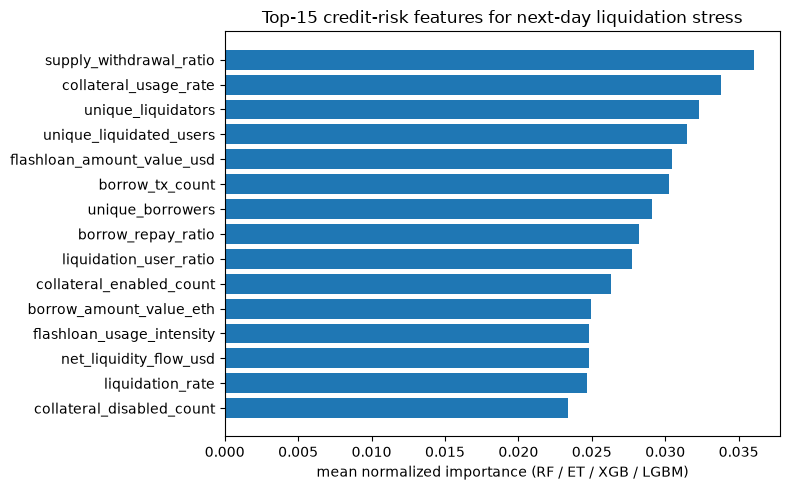

In [23]:
imp = mbench.aggregate_feature_importances(results, top_n=15)
display(imp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"][::-1], imp["mean_importance"][::-1])
ax.set_xlabel("mean normalized importance (RF / ET / XGB / LGBM)")
ax.set_title("Top-15 credit-risk features for next-day liquidation stress")
plt.tight_layout()
plt.show()

## Stage 6 — the PRI series

Blend composition, distribution, riskiest days (NEXT-day outcomes), and the
test-only lead-time backtest.

In [24]:
res_pri = results["meta_pri__meta"]
conc = mbench.weight_concentration(res_pri["weights"])
print(f" blend: {conc['n_nonzero']} of {res_pri['n_components']} components | "
      f"effective_n {conc['effective_n']} | max weight {conc['max_weight']}")
print(" weights:", {k: round(v, 3) for k, v in
                    sorted(res_pri["weights"].items(), key=lambda kv: -kv[1])})
temp = adv.statistical_validation(pri, columns=["pri"], save=False)
display(temp[["column", "null_pct", "mean", "cv", "p95", "skewness", "excess_kurtosis"]])
pri_chg = pri["pri"].diff().dropna()
print(f" PRI daily-change tails: VaR95 {EDA.value_at_risk(pri_chg):.2f} | "
      f"CVaR95 {EDA.conditional_var(pri_chg):.2f} | "
      f"max drawdown {EDA.max_drawdown(pri['pri']):.2f}")

 blend: 15 of 15 components | effective_n 13.2 | max weight 0.106
 weights: {'transformer': 0.106, 'lstm': 0.098, 'xgboost': 0.092, 'extra_trees': 0.092, 'random_forest': 0.086, 'cox_ph': 0.076, 'mlp': 0.073, 'hist_gradient_boosting': 0.07, 'lightgbm': 0.069, 'kneighbors': 0.053, 'gaussian_nb': 0.047, 'svc_rbf': 0.041, 'isolation_forest': 0.032, 'logistic_regression': 0.032, 'ridge_classifier': 0.032}


,column,null_pct,mean,cv,p95,skewness,excess_kurtosis
0,pri,0.0,53.028079,0.365467,82.949113,-0.177913,-0.809071


 PRI daily-change tails: VaR95 30.35 | CVaR95 34.46 | max drawdown 0.87


In [25]:
# top-10 riskiest days by PRI, with the realized NEXT-day liquidation outcome
pri_scores = results["meta_pri__meta"]["predictions"]
top10 = mbench.riskiest_days(pri_scores, DF_model, k=10)
display(top10)

,time_bucket,split,pri,y_true,next_day_liquidation_debt_covered_value_usd
0,2025-08-13 00:00:00.000 UTC,train,92.035827,1,1.804114e+06
1,2025-08-09 00:00:00.000 UTC,train,91.253923,1,1.079500e+06
2,2025-08-18 00:00:00.000 UTC,train,91.196005,1,3.967545e+06
3,2025-08-23 00:00:00.000 UTC,train,90.627181,1,3.859059e+06
4,2025-07-31 00:00:00.000 UTC,train,90.441785,1,6.329896e+06
5,2025-07-21 00:00:00.000 UTC,train,90.336556,1,7.024246e+05
6,2025-08-07 00:00:00.000 UTC,train,90.226053,1,2.706448e+06
7,2025-08-08 00:00:00.000 UTC,train,89.133424,1,1.684617e+05
8,2025-08-24 00:00:00.000 UTC,train,88.990233,1,2.467341e+06
9,2025-08-14 00:00:00.000 UTC,train,88.916681,1,4.264390e+05


In [26]:
# lead-time backtest — TEST split only (val tuned the blend and the sequence nets)
data = mps.load_model_data()
thr_1d = data["thresholds"][1]
stress_full = pri_scores.merge(
    DF_model[["time_bucket", "liquidation_debt_covered_value_usd"]],
    on="time_bucket", how="left")
stress_flags = (stress_full.sort_values("time_bucket", kind="stable")
                ["liquidation_debt_covered_value_usd"].astype(float) > thr_1d).astype(int)
events, summary = mbench.lead_time_backtest(pri_scores, stress_flags)
display(events)
print(" lead-time summary (test only):")
for k, v in summary.items():
    print(f"   {k}: {v}")
n_test_days = int((pri_scores["split"] == "test").sum())
print(f" context: {summary['n_alert_days']} alert days across {n_test_days} test days — "
      f"a median lead at the 7d window cap means saturated alerts, not sharper foresight")

 loaded splits [189, 82, 72] rows, 53 features (21 log1p, 0 dropped)


,time_bucket,split,pri_on_day,alerted_before,lead_days,alert_same_day
0,2026-01-12 00:00:00.000 UTC,test,44.3,False,None,False
1,2026-01-15 00:00:00.000 UTC,test,59.8,False,None,False
2,2026-01-19 00:00:00.000 UTC,test,74.5,False,None,False
3,2026-01-25 00:00:00.000 UTC,test,71.2,False,None,False
4,2026-01-29 00:00:00.000 UTC,test,64.8,False,None,False
5,2026-02-11 00:00:00.000 UTC,test,63.3,False,None,False
6,2026-02-13 00:00:00.000 UTC,test,47.4,False,None,False
7,2026-02-18 00:00:00.000 UTC,test,40.3,False,None,False
8,2026-02-24 00:00:00.000 UTC,test,61.0,False,None,False
9,2026-02-28 00:00:00.000 UTC,test,67.7,False,None,False


 lead-time summary (test only):
   alert_threshold_pri: 82.2
   n_stress_episodes: 17
   n_alerted_before: 0
   hit_rate: 0.0
   median_lead_days: nan
   mean_lead_days: nan
   n_alert_days: 0
   n_false_alerts: 0
   false_alert_rate: nan
 context: 0 alert days across 72 test days — a median lead at the 7d window cap means saturated alerts, not sharper foresight


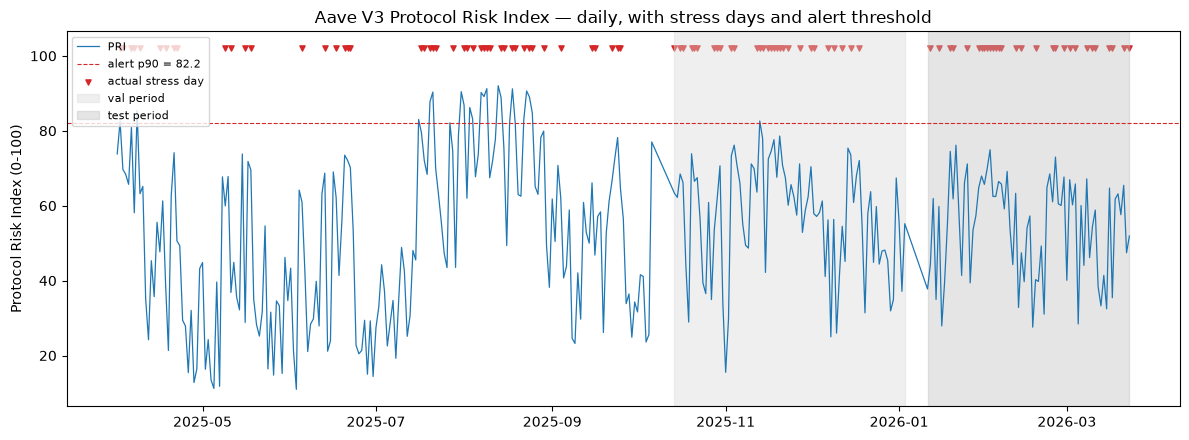

In [27]:
# PRI timeline with alert threshold, stress days and split boundaries
f = pri_scores.sort_values("time_bucket", kind="stable").reset_index(drop=True)
days = pd.to_datetime(f["time_bucket"].str.replace(" UTC", "", regex=False))
alert_thr = summary["alert_threshold_pri"]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(days, f["score"], lw=0.9, label="PRI")
ax.axhline(alert_thr, ls="--", lw=0.8, color="tab:red", label=f"alert p90 = {alert_thr}")
stress_days = days[stress_flags.to_numpy().astype(bool)]
ax.scatter(stress_days, [102] * len(stress_days), marker="v", s=14,
           color="tab:red", label="actual stress day")
for s, color in (("val", "0.85"), ("test", "0.75")):
    seg = days[(f["split"] == s).to_numpy()]
    ax.axvspan(seg.iloc[0], seg.iloc[-1], color=color, alpha=0.4, label=f"{s} period")
ax.set_ylabel("Protocol Risk Index (0-100)")
ax.set_title("Aave V3 Protocol Risk Index — daily, with stress days and alert threshold")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## FINAL — the only cross-family comparison

Champion selected on VAL (selection never touches test), then compared on test
against the meta-PRI and the persistence baseline, CIs alongside.

In [28]:
champ_name, champ_val, champ_test = mbench.select_champion(results)
champ_ci = next(r for r in results.values()
                if r.get("name") == champ_name).get("test_auc_ci", {})
meta = results["meta_pri__meta"]["targets"]["y_stress_1d"]["test"]
meta_ci = results["meta_pri__meta"].get("test_auc_ci", {})
base = results["baseline_persistence__classifier"]["targets"]["y_stress_1d"]["test"]

print("═" * 72)
print(" AAVE V3 CREDIT-RISK — FINAL BENCHMARK (test split, 1d stress)")
print("═" * 72)
print(f" baseline (persistence)     : ROC-AUC {base['roc_auc']:.3f}")
print(f" champion [{champ_name}] — picked on val {champ_val['roc_auc']:.3f}")
print(f"   test                     : ROC-AUC {champ_test['roc_auc']:.3f} "
      f"[{champ_ci.get('lo', float('nan')):.3f}, {champ_ci.get('hi', float('nan')):.3f}]")
print(f" meta PRI                   : ROC-AUC {meta['roc_auc']:.3f} "
      f"[{meta_ci.get('lo', float('nan')):.3f}, {meta_ci.get('hi', float('nan')):.3f}]")
conc = mbench.weight_concentration(results["meta_pri__meta"]["weights"])
print(f" PRI blend                  : {conc['n_nonzero']} of "
      f"{results['meta_pri__meta']['n_components']} components | "
      f"effective_n {conc['effective_n']} (max {conc['max_weight']})")
print(f" best volume regressor      : {best_reg['model']} — R² {best_reg['r2']:.3f}, "
      f"MAE ${best_reg['mae_usd']:,.0f}")
print(f" stress episodes (test)     : {summary['n_alerted_before']}/{summary['n_stress_episodes']} "
      f"flagged | median lead {summary['median_lead_days']}d | "
      f"false-alert rate {summary['false_alert_rate']:.0%}")
overlap = not (meta_ci.get("lo", 0) > champ_ci.get("hi", 1)
               or champ_ci.get("lo", 0) > meta_ci.get("hi", 1))
if overlap:
    print(" note: champion and PRI CIs overlap — no significant winner at 95%")

════════════════════════════════════════════════════════════════════════
 AAVE V3 CREDIT-RISK — FINAL BENCHMARK (test split, 1d stress)
════════════════════════════════════════════════════════════════════════
 baseline (persistence)     : ROC-AUC 0.509
 champion [transformer] — picked on val 0.639
   test                     : ROC-AUC 0.554 [0.351, 0.738]
 meta PRI                   : ROC-AUC 0.540 [0.389, 0.694]
 PRI blend                  : 15 of 15 components | effective_n 13.2 (max 0.106)
 best volume regressor      : ridge — R² -0.051, MAE $6,108,780
 stress episodes (test)     : 0/17 flagged | median lead nand | false-alert rate nan%
 note: champion and PRI CIs overlap — no significant winner at 95%
